# Get to Know a Dataset: CTrees CONUS Canopy Height & Cover at 30 m

This notebook is a guided tour of CTrees' **CONUS canopy tree height and cover at 30 m**,
derived from NAIP aerial imagery and published as an [Icechunk](https://icechunk.io)
repository on [Arraylake](https://docs.earthmover.io).

More usage examples, tutorials, and documentation for this dataset and others can be
found at the [Registry of Open Data on AWS](https://registry.opendata.aws/).

> **TODO before publishing:** link the Registry of Open Data landing page for this
> dataset once the entry is live.

**The question this notebook answers:** *Where is California's canopy structurally
complex, and where is it uniform?*

This dataset ships two variables that its 5 m sibling does not: `tree_height_mean` and
`tree_height_std`, the mean and standard deviation of the native 60 cm height
predictions inside each 30 m cell. `tree_height_std` is a direct measurement of
**within-cell structural heterogeneity** — how much the canopy varies over 30 metres.
That turns out to separate planted canopy from natural forest rather cleanly, and it is
a question you can only ask at this resolution, because the 5 m product does not carry
the within-cell distribution at all.

## Before you start

Create the environment and authenticate once, from a terminal:

```sh
conda env create -f environment.yml
conda activate ctrees-tree-height-env

al auth login      # opens a browser; caches a session locally
```

`al auth login` is the only authentication step. **This notebook never reads an API
key or token** — `arraylake.Client()` picks up the cached session automatically.

### Q: How have you organized your dataset?

The dataset is a single Icechunk repository, `ctrees/tree-height-naip-30m-conus`, on
Arraylake, organised as **one Zarr group per state**, named by its two-letter postal
code:

```
ctrees/tree-height-naip-30m-conus       <- Icechunk repository
└── branch: main
    ├── AL/                             <- one Zarr group per state (48 CONUS states)
    ├── AR/
    ├── ...
    └── CA/
        ├── tree_height             (time, y, x)  uint8    <- metres, MEDIAN
        ├── tree_height_mean        (time, y, x)  float32  <- metres, MEAN
        ├── tree_height_std         (time, y, x)  float32  <- metres, STD DEV
        ├── tree_cover              (time, y, x)  uint8    <- 0 = non-forest, 1 = forest
        ├── tree_cover_percentage   (time, y, x)  uint8    <- whole percent, 0-100
        ├── time                                           <- NAIP acquisition years
        ├── y, x                                           <- EPSG:4326 pixel centres
        └── spatial_ref                                    <- CRS metadata (scalar)
```

**Why one group per state?** NAIP flies on a state-by-state cycle, so each state has
its own acquisition years — Alabama 2021 and 2023, California 2020 and 2022, Nevada only
2022. Four states have non-contiguous year sets. A shared time axis would have
fabricated phantom, entirely-nodata years, so **each state group carries its own `time`
coordinate**. Check it per state rather than assuming.

**Grid.** One globally-aligned EPSG:4326 grid with a step of `0.00025°` (1/4000 of a
degree, about 27.64 m of latitude), pixel edges at exact multiples of that step from
(-180, +90). Arrays are chunked `512 x 512` and sharded `2048 x 2048`.

**This is not a downsampled version of the 5 m product.** Both reduce the same native
**60 cm** NAIP predictions directly — they are siblings, not parent and child. The two
grids are also deliberately **not pixel-nested** (0.00025 / 0.00004 = 6.25, and the
underlying sources are not nested either), so comparing the two resolutions requires an
explicit resample, never a plain `.sel()`.

**Coverage is not uniform.** Each state's array spans its bounding box, but NAIP
coverage within it is partial — California is about 46% populated. Absent regions read
as the fill value, not as an error.

In [1]:
# This notebook requires the following libraries. Install them with the supplied
# environment.yml (see "Before you start" above):
#
# arraylake >= 1.6
# icechunk == 2.2.2
# xarray >= 2025.1
# zarr >= 3
# dask
# rioxarray >= 0.18
# matplotlib >= 3.8
# numpy >= 2.0
# pandas >= 2.0

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import zarr
import dask

from arraylake import Client

# Dask defaults to one worker thread per CPU core, which puts that many decoded
# chunks in flight at once. These arrays decode to float32, so on a laptop that
# is the difference between running comfortably and swapping. Raise it on a
# larger machine; lower it further if you are memory-constrained.
dask.config.set(scheduler="threads", num_workers=4)

Connect to Arraylake and open the repository. `Client()` takes no arguments — it uses
the session cached by `al auth login`.

In [2]:
REPO = "ctrees/tree-height-naip-30m-conus"
BRANCH = "test-ingest"

client = Client()
repo = client.get_repo(REPO)

# A read-only session pins every read to a single snapshot, so a long analysis cannot
# see the dataset change underneath it.
session = repo.readonly_session(branch=BRANCH)

root = zarr.open_group(session.store, mode="r")
states = sorted(root.group_keys())
print(f"{len(states)} state groups:")
print(", ".join(states))

48 state groups:
AL, AR, AZ, CA, CO, CT, DE, FL, GA, IA, ID, IL, IN, KS, KY, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, OR, PA, RI, SC, SD, TN, TX, UT, VA, VT, WA, WI, WV, WY


Open California. `chunks={}` keeps the arrays lazy — essential here, because
California's array is roughly two billion pixels per variable-year, which is about
8 GB for each of the two `float32` statistics bands.

In [3]:
STATE = "CA"
YEAR = 2022

ds = xr.open_zarr(session.store, group=STATE, zarr_format=3, chunks={})
print("Acquisition years for", STATE, ":", list(ds.time.dt.year.values))
ds

Acquisition years for CA : [np.int64(2020), np.int64(2022)]


<xarray.Dataset> Size: 70GB
Dimensions:                (time: 2, y: 40960, x: 43008)
Coordinates:
  * time                   (time) datetime64[ns] 16B 2020-01-01 2022-01-01
  * y                      (y) float64 328kB 42.38 42.38 42.38 ... 32.14 32.14
  * x                      (x) float64 344kB -124.7 -124.7 ... -114.0 -114.0
    spatial_ref            int64 8B ...
Data variables:
    tree_cover             (time, y, x) float32 14GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_height_mean       (time, y, x) float32 14GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_height            (time, y, x) float32 14GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_height_std        (time, y, x) float32 14GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    tree_cover_percentage  (time, y, x) float32 14GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.8
    title:                  CONUS NAIP-derived Canopy Tree Height and Cover, 30m
    state:                  CA
    temporal_resolution:    annual composite
    years:                  [2020, 2022]
    source_grid:            Planet L15 (EPSG:3857, 2048x2048 quads), warped t...
    grid:                   regular EPSG:4326, 0.00025 deg, globally aligned ...
    nominal_resolution_m:   27.643
    area_calculation_note:  This is a regular latitude/longitude grid, which ...

In [4]:
for name in ("tree_height", "tree_height_mean", "tree_height_std",
             "tree_cover", "tree_cover_percentage"):
    v = ds[name]
    print(f"{name}")
    print(f"    dtype in memory  {v.dtype}        <- decoded")
    print(f"    dtype in storage {v.encoding.get('dtype')}        <- as stored")
    print(f"    fill value       {v.encoding.get('_FillValue')}")
    print(f"    units            {v.attrs.get('units', '-')}")
    print(f"    cell_methods     {v.attrs.get('cell_methods', '-')}")
    print(f"    resampling       {v.attrs.get('resampling', '-')}")
    print()

tree_height
    dtype in memory  float32        <- decoded
    dtype in storage uint8        <- as stored
    fill value       255
    units            meters
    cell_methods     area: median
    resampling       average

tree_height_mean
    dtype in memory  float32        <- decoded
    dtype in storage float32        <- as stored
    fill value       -9999.0
    units            meters
    cell_methods     area: mean
    resampling       average

tree_height_std
    dtype in memory  float32        <- decoded
    dtype in storage float32        <- as stored
    fill value       -9999.0
    units            meters
    cell_methods     area: standard_deviation
    resampling       average

tree_cover
    dtype in memory  float32        <- decoded
    dtype in storage uint8        <- as stored
    fill value       255
    units            -
    cell_methods     -
    resampling       nearest

tree_cover_percentage
    dtype in memory  float32        <- decoded
    dtype in storage uint

#### The three height variables are three different statistics

This is the single most important thing to understand about this dataset, and the
thing most likely to look like a bug if you do not know it.

| variable | `cell_methods` | what it is |
|---|---|---|
| `tree_height` | `area: median` | **median** of the 60 cm height predictions in the cell |
| `tree_height_mean` | `area: mean` | **mean** of the same predictions |
| `tree_height_std` | `area: standard_deviation` | their **standard deviation** |

Canopy heights within a cell are right-skewed — a few tall crowns pull the upper tail —
so **the mean sits above the median wherever there is canopy**. Measured across a
published state, the mean exceeds the median at **65% of vegetated pixels**, with a
correlation of 0.984 and a mean absolute difference of 0.69 m. That is the expected
relationship, not a defect. If you compare `tree_height` against another product's mean
height, you will find a systematic offset that is entirely explained by this.

Two consequences for practical work:

- **`tree_height_mean − tree_height` is a skew measure.** Where it is large, the cell
  contains a few crowns much taller than typical.
- **The two statistics bands are `float32`, with a fill value of `-9999`** — not 255 as
  for the `uint8` variables. Their sub-metre precision is the point of them, so they
  are stored at full precision rather than quantised to whole metres.

**You do not have to mask either sentinel yourself.** xarray's default CF decoding
replaces both with `NaN` on open, which is why every variable above is `float32` in
memory regardless of how it is stored. The distinction still matters in two cases: if
you open with `mask_and_scale=False`, or if you read through `zarr` directly. Then the
raw `255`s and `-9999`s come through as data, and mixing up which belongs to which
variable is silent and costly.

### Q: What data formats are present in your dataset?

#### Zarr

[Zarr](https://zarr.dev) stores chunked, compressed, N-dimensional arrays in a layout
built for cloud object storage. Instead of one monolithic file, a store is a collection
of small objects, so a reader fetches exactly the subset it needs. These arrays are
**Zarr v3 and sharded** — the chunk is `512 x 512`, but 16 chunks are packed into one
`2048 x 2048` shard object, keeping the object count manageable without forcing readers
to download a whole shard for one chunk.

#### Icechunk

[Icechunk](https://icechunk.io) adds Git-like version control on top of Zarr:

- **Branches** — `main` is the authoritative version; authors may keep others for
  experiments or alternative processing runs.
- **Snapshots (commits)** — every update is recorded, so the dataset is reproducible at
  any point in its history.
- **Sessions** — `readonly_session` pins your reads to one snapshot.

The workflow is: open the repo → open a read-only session → hand `session.store` to
`xarray`.

#### Recommended tooling

`xarray` for labelled access and `dask` (via `chunks={}`) to keep large reads lazy —
at this scale, loading eagerly is the main way to get into trouble. `rioxarray` for
CRS-aware clipping and GeoTIFF export.

#### Multiscale overviews

The repository also carries a GeoZarr overview pyramid at 4x (about 110 m) on a separate
branch, which renders directly in the Earthmover viewer and through its Flux tile
service. For *visualising* a whole state, that pyramid is far cheaper than coarsening
the native arrays yourself. This notebook reads native resolution so that the statistics
are computed on the real data, but the state-wide map near the end is exactly the case
where you would reach for the overviews instead.

### Q: Can you show us an example of downloading and loading data?

We will pull three small windows from California with visibly different canopy
structure, and compare them.

- **Central Valley orchards** — almond and pistachio groves near Fresno. Planted on a
  grid, even-aged, uniform height.
- **Sierra Nevada mixed conifer** — near Shaver Lake. Natural, multi-layered, uneven-aged.
- **Coast redwood** — inland Humboldt County. Tall and structurally complex.

All three are fully covered by NAIP in 2022.

In [8]:
# (min_lon, min_lat, max_lon, max_lat)
REGIONS = {
    "Central Valley orchards": (-120.30, 36.75, -119.95, 37.05),
    "Sierra mixed conifer":    (-119.50, 37.00, -119.10, 37.35),
    "Coast redwood":           (-124.10, 40.30, -123.80, 40.60),
}

VARIABLES = ("tree_height", "tree_height_mean", "tree_height_std",
             "tree_cover", "tree_cover_percentage")

def load_region(bbox, year=YEAR):
    # Crop first -- cropping is what keeps the read small. No manual fill masking:
    # xarray decoded 255 and -9999 to NaN when we opened the dataset.
    minx, miny, maxx, maxy = bbox
    # NOTE: y descends (north-up), so the slice runs maxy -> miny.
    win = ds.sel(x=slice(minx, maxx), y=slice(maxy, miny)).sel(time=f"{year}-01-01")
    return win[list(VARIABLES)].compute()

regions = {name: load_region(bbox) for name, bbox in REGIONS.items()}

for name, r in regions.items():
    valid = float(r.tree_height.notnull().mean()) * 100
    print(f"{name:26s} {dict(r.sizes)}  valid: {valid:5.1f}%")

Central Valley orchards    {'y': 1200, 'x': 1400}  valid: 100.0%
Sierra mixed conifer       {'y': 1400, 'x': 1600}  valid: 100.0%
Coast redwood              {'y': 1200, 'x': 1200}  valid: 100.0%


### Q: A picture is worth a thousand words

For each region: canopy height (the median), and the within-cell standard deviation.
Watch the second row — the orchards almost vanish.

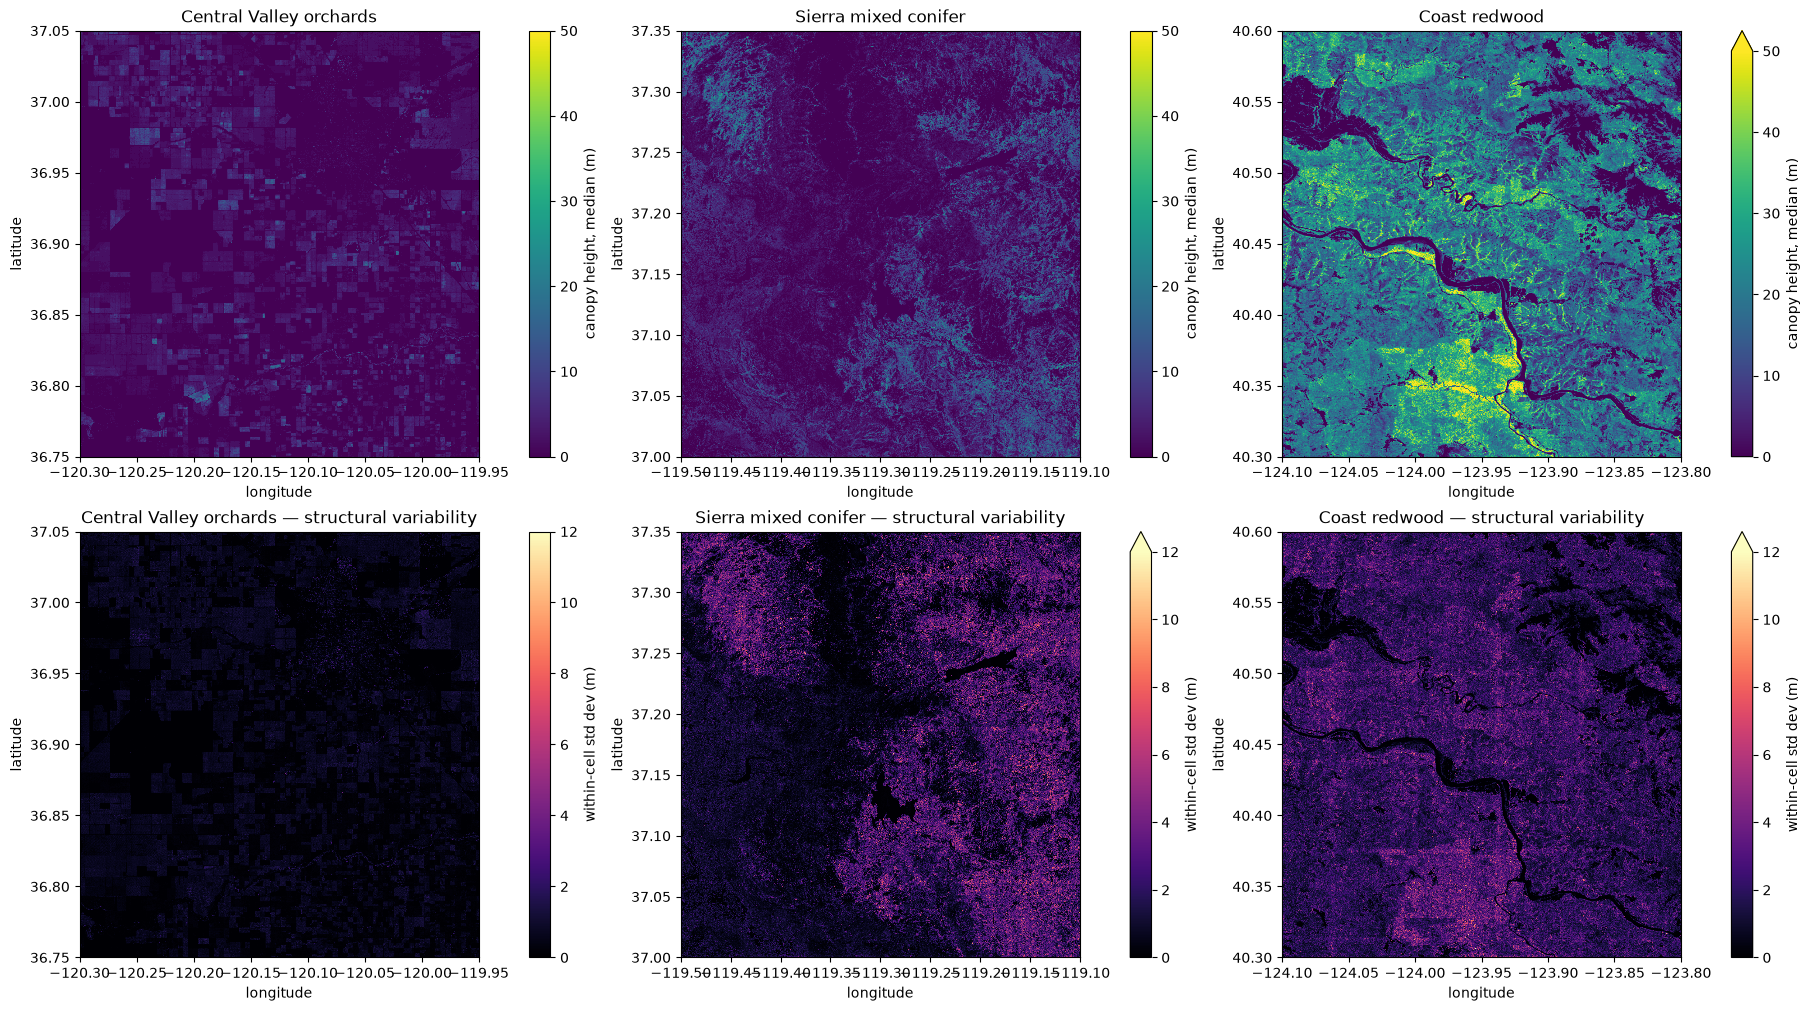

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for col, (name, r) in enumerate(regions.items()):
    r.tree_height.plot(ax=axes[0, col], vmin=0, vmax=50, cmap="viridis",
                       cbar_kwargs={"label": "canopy height, median (m)"})
    axes[0, col].set_title(name)

    r.tree_height_std.plot(ax=axes[1, col], vmin=0, vmax=12, cmap="magma",
                           cbar_kwargs={"label": "within-cell std dev (m)"})
    axes[1, col].set_title(f"{name} — structural variability")

for ax in axes.ravel():
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.show()

### Q: What is one question you have answered using these data?

**Where is California's canopy structurally complex, and where is it uniform — and can
`tree_height_std` tell planted canopy from natural forest?**

The intuition is simple. An almond orchard is planted on a grid, all the trees are the
same age and the same species, and they are pruned to the same height. Within any
30 m cell, the canopy barely varies — so `tree_height_std` should be small *even where
the canopy is tall and dense*. A natural mixed-conifer stand is uneven-aged and
multi-layered: tall emergent crowns over a shorter understorey, with gaps. Within the
same 30 m cell, height varies a lot.

If that holds, `tree_height_std` separates the two even when `tree_height` and
`tree_cover` cannot — because a mature orchard and a mature forest can look nearly
identical in height and cover alone.

Let's test it. We restrict to vegetated cells, since bare ground is trivially uniform
and would swamp the comparison.

In [10]:
VEG_MIN_HEIGHT_M = 0.0   # ignore bare ground, water, and low scrub

rows = []
for name, r in regions.items():
    veg = r.tree_height >= VEG_MIN_HEIGHT_M
    h = r.tree_height.where(veg)
    s = r.tree_height_std.where(veg)
    m = r.tree_height_mean.where(veg)
    rows.append({
        "region": name,
        "vegetated cells": int(veg.sum()),
        "median height (m)": float(h.median()),
        "mean of means (m)": float(m.mean()),
        "mean std dev (m)": float(s.mean()),
        "median std dev (m)": float(s.median()),
        "skew: mean - median (m)": float((m - h).mean()),
        "cover (%)": float(r.tree_cover_percentage.where(veg).mean()),
    })

summary = pd.DataFrame(rows).set_index("region")
summary.round(2)

,vegetated cells,median height (m),mean of means (m),mean std dev (m),median std dev (m),skew: mean - median (m),cover (%)
region,,,,,,,
Central Valley orchards,1680000,0.0,1.67,0.36,0.26,0.35,19.68
Sierra mixed conifer,2240000,2.0,5.40,1.58,1.11,1.76,73.41
Coast redwood,1440000,18.0,18.52,1.93,1.79,0.63,90.50


Now the distributions, which make the separation clearer than any summary statistic.

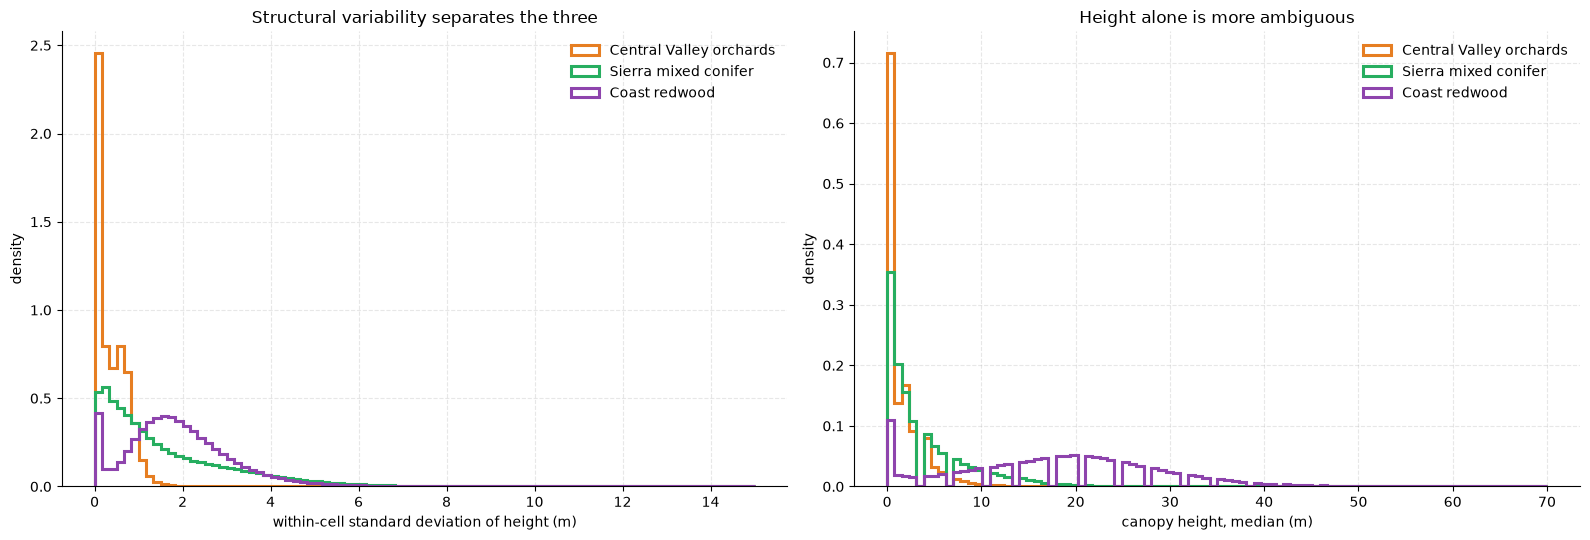

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

colours = {"Central Valley orchards": "#e67e22",
           "Sierra mixed conifer": "#27ae60",
           "Coast redwood": "#8e44ad"}

for name, r in regions.items():
    veg = r.tree_height >= VEG_MIN_HEIGHT_M
    s = r.tree_height_std.where(veg).values.ravel()
    s = s[~np.isnan(s)]
    axes[0].hist(s, bins=90, range=(0, 15), density=True, histtype="step",
                 linewidth=2.2, label=name, color=colours[name])

    h = r.tree_height.where(veg).values.ravel()
    h = h[~np.isnan(h)]
    axes[1].hist(h, bins=90, range=(0, 70), density=True, histtype="step",
                 linewidth=2.2, label=name, color=colours[name])

axes[0].set_xlabel("within-cell standard deviation of height (m)")
axes[0].set_ylabel("density")
axes[0].set_title("Structural variability separates the three")
axes[1].set_xlabel("canopy height, median (m)")
axes[1].set_ylabel("density")
axes[1].set_title("Height alone is more ambiguous")

for ax in axes:
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

The left panel is the result. Orchard cells cluster at low standard deviation; the two
natural forest types sit well to the right, with redwood the broadest of all. The right
panel is the control: height alone overlaps far more, which is the point — the
structural signal is carrying information that the median height does not.

#### Scaling this up: a state-wide view

The same statistic can be mapped across all of California. Be aware of the cost: the
state array is roughly two billion pixels per variable-year, so the cell below reads
several GB and will take a few minutes depending on your connection. It is lazy and
chunk-streamed, so it will not exhaust memory — but it is not instant.

**If you only want to look at it**, the overview pyramid on the repository's overviews
branch holds a pre-computed 4x (about 110 m) level that renders directly in the
Earthmover viewer and through its Flux tile service, and is far cheaper than coarsening
the native array yourself. Coarsen the native data when you need the *numbers* to be
computed from real pixels, as here.

In [12]:
# Coarsen to roughly 2.8 km blocks for a tractable state-wide map.
# This reads the full-resolution array and reduces it as it streams.
BLOCK = 100

std_ca = ds.tree_height_std.sel(time=f"{YEAR}-01-01")
hgt_ca = ds.tree_height.sel(time=f"{YEAR}-01-01")

# Only vegetated cells contribute, so bare ground does not drag the mean to zero.
veg_ca = hgt_ca >= VEG_MIN_HEIGHT_M

std_coarse = std_ca.where(veg_ca).coarsen(y=BLOCK, x=BLOCK, boundary="trim").mean()
std_coarse = std_coarse.compute()
print("Coarsened state grid:", dict(std_coarse.sizes))

Coarsened state grid: {'y': 409, 'x': 430}


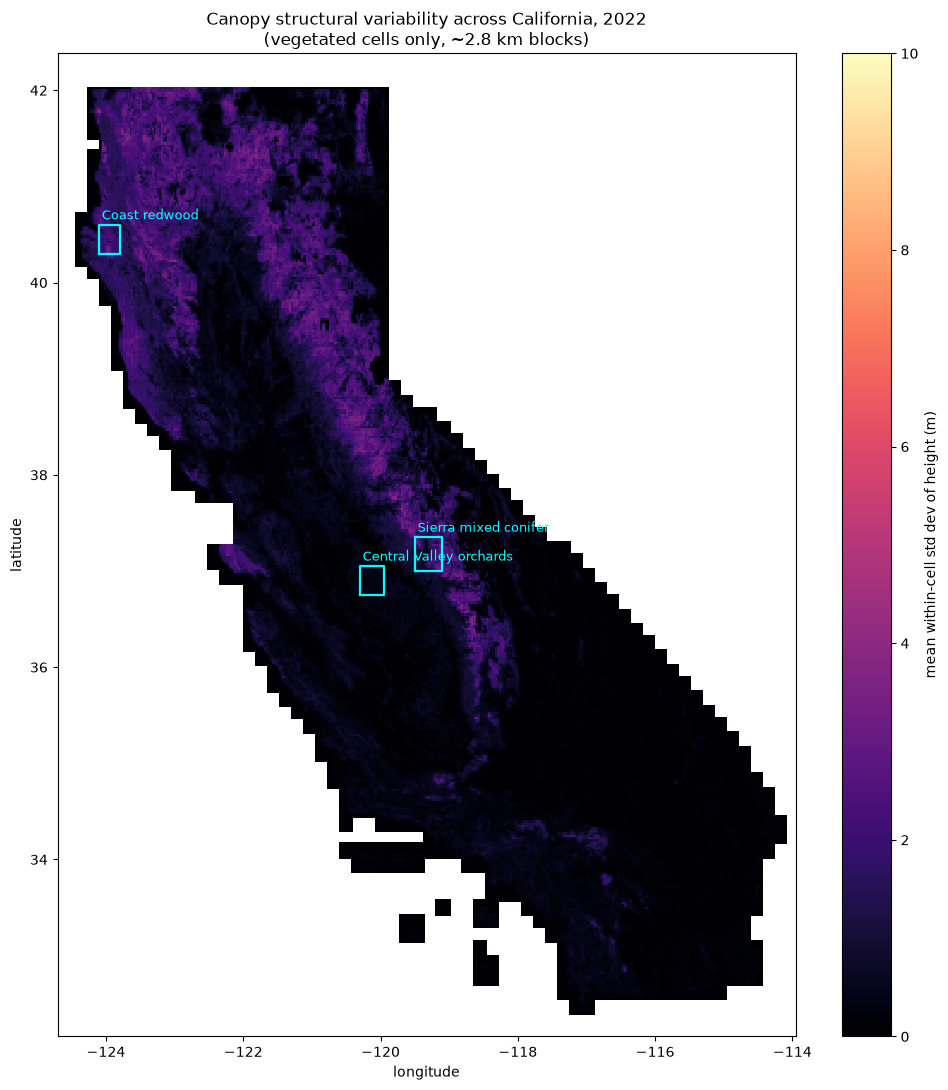

In [13]:
fig, ax = plt.subplots(figsize=(10, 11))

std_coarse.plot(ax=ax, vmin=0, vmax=10, cmap="magma",
                cbar_kwargs={"label": "mean within-cell std dev of height (m)"})

for name, (minx, miny, maxx, maxy) in REGIONS.items():
    ax.plot([minx, maxx, maxx, minx, minx], [miny, miny, maxy, maxy, miny],
            color="cyan", linewidth=1.6)
    ax.annotate(name, (minx, maxy), color="cyan", fontsize=9,
                xytext=(2, 4), textcoords="offset points")

ax.set_title(f"Canopy structural variability across California, {YEAR}\n"
             "(vegetated cells only, ~2.8 km blocks)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.show()

#### How to read this result

**The Central Valley reads as a low-variability band** running down the middle of the
state, flanked by high-variability Sierra and Coast Range forest. That is the orchard
signal at state scale.

**Caveats worth stating plainly:**

- **Low variability is not uniquely orchards.** Even-aged plantation forest, recently
  regenerated stands and some chaparral are also structurally uniform. This separates
  *structure*, not *land use*; turning it into a land-use classifier would need training
  labels, which is the next question.
- **`tree_height_std` is a within-cell statistic, computed from the 60 cm source.** It
  is not the variability between neighbouring 30 m cells, which is a different and also
  useful quantity you can compute yourself from `tree_height`.
- **Blank areas are missing NAIP coverage, not treeless ground.** California is roughly
  46% populated in this dataset. Absent regions read as fill.
- **If you go on to compute areas, do not count pixels.** This is a regular
  latitude/longitude grid and is not equal-area; cell ground area varies as
  `cos(latitude)`. Use the spherical zone formula
  `R² · Δλ · (sin φ_n − sin φ_s)`, or reproject to an equal-area CRS (EPSG:5070 for
  CONUS, EPSG:6933 globally) first.

### Q: What is one unanswered question that could be answered using these data?

**Can within-cell canopy structure, measured at 30 m across all of CONUS, be turned into
a national map of managed versus natural canopy — and how much carbon sits in each?**

The orchard-versus-forest separation above is suggestive but unlabelled. Turning it into
a product means supervised classification, and the ingredients are unusually good: a
structural feature (`tree_height_std`), a height feature (`tree_height`), a skew feature
(`tree_height_mean − tree_height`) and a density feature (`tree_cover_percentage`) — four
largely independent views of canopy structure, wall to wall, at a resolution where
national-scale work is actually tractable.

Someone could:

1. **Train on existing labels.** USDA CropScape identifies orchard and vineyard crops
   nationally; the USFS Forest Inventory and Analysis plots give stand age and structure
   for natural forest. Both are public, and both can supply labelled cells.
2. **Test transferability across states.** A classifier trained on California orchards
   and Sierra conifer — does it hold in Georgia pine plantations, or in New England
   mixed hardwood? NAIP's acquisition years differ by state, which is itself a confound
   worth measuring.
3. **Attach carbon to the result.** Managed and natural canopy have very different
   carbon dynamics and very different permanence. Joining this classification to CTrees'
   [100 m above-ground biomass product](https://registry.opendata.aws/) would estimate
   how much of CONUS canopy carbon sits in actively managed systems.

**Recommendations for someone tackling this:**

- **Work state by state, in parallel.** The per-state group layout makes this the
  natural unit — one worker per state, each with its own session. Do not try to build a
  single CONUS-wide array.
- **Keep reads lazy.** `chunks={}`, crop before you compute, and never call `.values` on
  a state-sized array. The failure mode is memory, and it arrives suddenly.
- **Mask the right sentinel.** `-9999` for the two `float32` statistics bands, `255` for
  the three `uint8` variables. Mixing them up is silent.
- **Mind the differing time axes.** Each state has its own acquisition years; a
  CONUS-wide composite is a mosaic of different years, not a snapshot. Say so in your
  figures.
- **Reach for the 5 m sibling where structure is sub-pixel.** Street trees and narrow
  riparian strips are below this product's resolution. The two grids are not
  pixel-nested, so crossing between them needs an explicit resample.

We would be glad to see what you find.

In [14]:
# Starter: assemble the four-feature table that a classifier would train on.

def feature_table(r, min_height=VEG_MIN_HEIGHT_M):
    veg = r.tree_height >= min_height
    return pd.DataFrame({
        "height_median": r.tree_height.where(veg).values.ravel(),
        "height_std": r.tree_height_std.where(veg).values.ravel(),
        "skew": (r.tree_height_mean - r.tree_height).where(veg).values.ravel(),
        "cover_pct": r.tree_cover_percentage.where(veg).values.ravel(),
    }).dropna()

features = pd.concat(
    [feature_table(r).assign(region=name) for name, r in regions.items()],
    ignore_index=True,
)

print(f"{len(features):,} labelled vegetated cells across the three regions")
print()
print(features.groupby("region")[["height_median", "height_std", "skew", "cover_pct"]]
      .mean().round(2))
print()
print("Next step: swap these three hand-picked regions for CropScape orchard labels")
print("and FIA plot locations, then fit a classifier and test it in another state.")

5,360,000 labelled vegetated cells across the three regions

                         height_median  height_std  skew  cover_pct
region                                                             
Central Valley orchards           1.32        0.36  0.35  19.680000
Coast redwood                    17.90        1.93  0.63  90.500000
Sierra mixed conifer              3.63        1.58  1.76  73.410004

Next step: swap these three hand-picked regions for CropScape orchard labels
and FIA plot locations, then fit a classifier and test it in another state.
